In [1]:
#imports 
import ray
import numpy as np
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from ray.train.xgboost import XGBoostTrainer
from ray.train import ScalingConfig
import xgboost as xgb

import pandas as pd
import matplotlib.pyplot as plt


if ray.is_initialized():
    ray.shutdown()

ray.init(num_cpus=8, ignore_reinit_error=True, logging_level="WARNING")


# 1. Load STEAD

LABEL_COL = "s_arrival_sample"

ds = ray.data.read_parquet(
    "/expanse/lustre/projects/uci157/ysuh2/data/stead_version4",
    shuffle="files"
).limit(5000)

print("Original rows:", ds.count())


# 2. Cast label to float

def cast_label(batch):
    batch[LABEL_COL] = batch[LABEL_COL].astype("float64")
    return batch

ds = ds.map_batches(cast_label, batch_format="numpy")


# 3. Filter invalid labels

def valid_label(row):
    y = row[LABEL_COL]
    return (y is not None) and (not np.isnan(y)) and (not np.isinf(y))

clean_ds = ds.filter(valid_label)
print("Rows after cleaning:", clean_ds.count())


Metadata Fetch Progress 0:   0%|          | 0.00/140 [00:00<?, ? task/s]

Parquet Files Sample 0:   0%|          | 0.00/8.00 [00:00<?, ? file/s]

/usr/local/lib/python3.10/dist-packages/ray/data/dataset.py:1331: UserWarning: Use 'expr' instead of 'fn' when possible for performant filters.
  warnings.warn(
2026-06-01 18:35:48,833	INFO streaming_executor.py:108 -- Starting execution of Dataset. Full logs are in /tmp/ray/ray/session_2026-06-01_18-35-34_696613_75041/logs/ray-data
2026-06-01 18:35:48,834	INFO streaming_executor.py:109 -- Execution plan of Dataset: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadParquet] -> LimitOperator[limit=5000] -> TaskPoolMapOperator[MapBatches(cast_label)->Filter(valid_label)] -> AggregateNumRows[AggregateNumRows]


Original rows: 5000


Running 0: 0.00 row [00:00, ? row/s]

- ReadParquet 1: 0.00 row [00:00, ? row/s]

- limit=5000 2: 0.00 row [00:00, ? row/s]

- MapBatches(cast_label)->Filter(valid_label) 3: 0.00 row [00:00, ? row/s]

- AggregateNumRows 4: 0.00 row [00:00, ? row/s]

Rows after cleaning: 5000


In [3]:
# 4. Fit PCA on sample

sample = clean_ds.take(2000)

n = np.vstack([row["waveform_N"] for row in sample])
z = np.vstack([row["waveform_Z"] for row in sample])
e = np.vstack([row["waveform_E"] for row in sample])

combined = np.hstack([n, z, e])

N_COMPONENTS = 50
pca = PCA(n_components=N_COMPONENTS)
pca.fit(combined)

print("Explained variance (first 10):", pca.explained_variance_ratio_[:10])



2026-06-01 18:45:31,522	INFO streaming_executor.py:108 -- Starting execution of Dataset. Full logs are in /tmp/ray/ray/session_2026-06-01_18-35-34_696613_75041/logs/ray-data
2026-06-01 18:45:31,523	INFO streaming_executor.py:109 -- Execution plan of Dataset: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadParquet] -> LimitOperator[limit=5000] -> TaskPoolMapOperator[MapBatches(cast_label)->Filter(valid_label)] -> LimitOperator[limit=2000]


Running 0: 0.00 row [00:00, ? row/s]

- ReadParquet 1: 0.00 row [00:00, ? row/s]

- limit=5000 2: 0.00 row [00:00, ? row/s]

- MapBatches(cast_label)->Filter(valid_label) 3: 0.00 row [00:00, ? row/s]

- limit=2000 4: 0.00 row [00:00, ? row/s]

Explained variance (first 10): [0.3423933  0.2866967  0.07086505 0.04401096 0.04122283 0.02464369
 0.01900533 0.01705314 0.01446454 0.01238646]


Our PCA shows that most of the waveform’s variation comes from one main pattern. The first component captures over half of all differences, and the next few add smaller adjustments.

In [4]:
# 5. Broadcast PCA to workers

pca_ref = ray.put(pca)

# 6. Apply PCA
def apply_pca(batch, pca):
    n = np.array(batch["waveform_N"].tolist())
    z = np.array(batch["waveform_Z"].tolist())
    e = np.array(batch["waveform_E"].tolist())

    combined = np.hstack([n, z, e])
    feats = pca.transform(combined)

    out = {f"pca_{i}": feats[:, i] for i in range(feats.shape[1])}
    out[LABEL_COL] = batch[LABEL_COL]
    return out

pca_ds = clean_ds.map_batches(
    lambda batch: apply_pca(batch, ray.get(pca_ref)),
    batch_format="numpy"
)

pca_ds = pca_ds.materialize()

# 7. Keep only PCA columns
def keep_pca_only(batch):
    cols = [f"pca_{i}" for i in range(N_COMPONENTS)] + [LABEL_COL]
    return {col: batch[col] for col in cols}

pca_ds = pca_ds.map_batches(keep_pca_only, batch_format="pandas")


2026-06-01 18:45:39,405	INFO streaming_executor.py:108 -- Starting execution of Dataset. Full logs are in /tmp/ray/ray/session_2026-06-01_18-35-34_696613_75041/logs/ray-data
2026-06-01 18:45:39,406	INFO streaming_executor.py:109 -- Execution plan of Dataset: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadParquet] -> LimitOperator[limit=5000] -> TaskPoolMapOperator[MapBatches(cast_label)->Filter(valid_label)->MapBatches(<lambda>)]


Running 0: 0.00 row [00:00, ? row/s]

- ReadParquet 1: 0.00 row [00:00, ? row/s]

- limit=5000 2: 0.00 row [00:00, ? row/s]

- MapBatches(cast_label)->Filter(valid_label)->MapBatches(<lambda>) 3: 0.00 row [00:00, ? row/s]

2026-06-01 18:45:39,819	WARNING progress_bar.py:120 -- Truncating long operator name to 100 characters. To disable this behavior, set `ray.data.DataContext.get_current().DEFAULT_ENABLE_PROGRESS_BAR_NAME_TRUNCATION = False`.


In [6]:
# 8. Train/Valid/Test split
train_ds, test_ds = pca_ds.train_test_split(test_size=0.3, shuffle=False)
test_ds, valid_ds = test_ds.train_test_split(test_size=0.5, shuffle=False)

print("Train rows:", train_ds.count())
print("Valid rows:", valid_ds.count())
print("Test rows:", test_ds.count())

Train rows: 3150
Valid rows: 675
Test rows: 675


In [7]:
# 9. HYPERPARAMETER SEARCH
base_params = {
    "objective": "reg:squarederror",
    "tree_method": "hist",
    "eval_metric": "rmse",
}

max_depth_list = [3, 5, 7]
eta_list = [0.01, 0.05, 0.1]
subsample_list = [0.7, 1.0]

search_results = []

for max_depth in max_depth_list:
    for eta in eta_list:
        for subsample in subsample_list:

            params = {
                **base_params,
                "max_depth": max_depth,
                "eta": eta,
                "subsample": subsample,
            }

            print(f"Training with params: max_depth={max_depth}, eta={eta}, subsample={subsample}")

            trainer = XGBoostTrainer(
                label_column=LABEL_COL,
                params=params,
                scaling_config=ScalingConfig(num_workers=4, use_gpu=False),
                datasets={"train": train_ds, "valid": valid_ds},
                num_boost_round=200,
            )

            result = trainer.fit()

            # Ray stores metrics like "valid-rmse"
            valid_rmse = result.metrics.get("valid-rmse", None)

            search_results.append({
                "max_depth": max_depth,
                "eta": eta,
                "subsample": subsample,
                "valid_rmse": valid_rmse,
            })

search_df = pd.DataFrame(search_results)
print(search_df)

Training with params: max_depth=3, eta=0.01, subsample=0.7
== Status ==
Current time: 2026-06-01 18:47:06 (running for 00:00:00.11)
Using FIFO scheduling algorithm.
Logical resource usage: 5.0/8 CPUs, 0/0 GPUs
Result logdir: /tmp/ray/ray/session_2026-06-01_18-35-34_696613_75041/artifacts/2026-06-01_18-47-04/XGBoostTrainer_2026-06-01_18-47-04/driver_artifacts
Number of trials: 1/1 (1 PENDING)


== Status ==
Current time: 2026-06-01 18:47:11 (running for 00:00:05.18)
Using FIFO scheduling algorithm.
Logical resource usage: 5.0/8 CPUs, 0/0 GPUs
Result logdir: /tmp/ray/ray/session_2026-06-01_18-35-34_696613_75041/artifacts/2026-06-01_18-47-04/XGBoostTrainer_2026-06-01_18-47-04/driver_artifacts
Number of trials: 1/1 (1 RUNNING)




(XGBoostTrainer pid=89966) Started distributed worker processes: 
(XGBoostTrainer pid=89966) - (node_id=db2ae9eb9829b6459e98a8038c3eae12c70bef9939977b5d014db5bb, ip=198.202.101.239, pid=90071) world_rank=0, local_rank=0, node_rank=0
(XGBoostTrainer pid=89966) - (node_id=db2ae9eb9829b6459e98a8038c3eae12c70bef9939977b5d014db5bb, ip=198.202.101.239, pid=90074) world_rank=1, local_rank=1, node_rank=0
(XGBoostTrainer pid=89966) - (node_id=db2ae9eb9829b6459e98a8038c3eae12c70bef9939977b5d014db5bb, ip=198.202.101.239, pid=90072) world_rank=2, local_rank=2, node_rank=0
(XGBoostTrainer pid=89966) - (node_id=db2ae9eb9829b6459e98a8038c3eae12c70bef9939977b5d014db5bb, ip=198.202.101.239, pid=90073) world_rank=3, local_rank=3, node_rank=0
(RayTrainWorker pid=90074) [18:47:15] Task [xgboost.ray-rank=00000001]:48b1502f1aa2b0e86ed441d501000000 got rank 1


== Status ==
Current time: 2026-06-01 18:47:16 (running for 00:00:10.19)
Using FIFO scheduling algorithm.
Logical resource usage: 5.0/8 CPUs, 0/0 GPUs
Result logdir: /tmp/ray/ray/session_2026-06-01_18-35-34_696613_75041/artifacts/2026-06-01_18-47-04/XGBoostTrainer_2026-06-01_18-47-04/driver_artifacts
Number of trials: 1/1 (1 RUNNING)




(SplitCoordinator pid=90436) Starting execution of Dataset. Full logs are in /tmp/ray/ray/session_2026-06-01_18-35-34_696613_75041/logs/ray-data
(SplitCoordinator pid=90436) Execution plan of Dataset: InputDataBuffer[Input] -> OutputSplitter[split(4, equal=True)]


(pid=90436) Running 0: 0.00 row [00:00, ? row/s]

...

(RayTrainWorker pid=106506) [18:53:14] Task [xgboost.ray-rank=00000001]:220e0954943e09684cd337b201000000 got rank 1 [repeated 3x across cluster]
(XGBoostTrainer pid=106408) [18:53:20] [0]	train-rmse:631.70647	valid-rmse:872.40971
(XGBoostTrainer pid=106408) [18:53:20] [1]	train-rmse:600.98857	valid-rmse:818.11272
(XGBoostTrainer pid=106408) [18:53:20] [2]	train-rmse:574.85161	valid-rmse:768.84712
(XGBoostTrainer pid=106408) [18:53:21] [3]	train-rmse:550.51595	valid-rmse:732.39087
(XGBoostTrainer pid=106408) [18:53:21] [4]	train-rmse:528.87652	valid-rmse:693.51804
(XGBoostTrainer pid=106408) [18:53:21] [5]	train-rmse:509.64595	valid-rmse:658.62866
(XGBoostTrainer pid=106408) [18:53:21] [6]	train-rmse:492.58956	valid-rmse:629.37550
(XGBoostTrainer pid=106408) [18:53:21] [7]	train-rmse:477.14101	valid-rmse:601.74209
(XGBoostTrainer pid=106408) [18:53:21] [8]	train-rmse:460.33707	valid-rmse:573.07045
(XGBoostTrainer pid=106408) [18:53:21] [9]	train-rmse:447.13539	valid-rmse:550.70943
(XGBo

== Status ==
Current time: 2026-06-01 18:53:25 (running for 00:00:20.23)
Using FIFO scheduling algorithm.
Logical resource usage: 5.0/8 CPUs, 0/0 GPUs
Result logdir: /tmp/ray/ray/session_2026-06-01_18-35-34_696613_75041/artifacts/2026-06-01_18-53-05/XGBoostTrainer_2026-06-01_18-53-05/driver_artifacts
Number of trials: 1/1 (1 RUNNING)




(XGBoostTrainer pid=106408) [18:53:25] [97]	train-rmse:78.43365	valid-rmse:328.27284
(XGBoostTrainer pid=106408) [18:53:25] [98]	train-rmse:76.94976	valid-rmse:328.36076
(XGBoostTrainer pid=106408) [18:53:25] [99]	train-rmse:75.17062	valid-rmse:328.43081
(XGBoostTrainer pid=106408) [18:53:25] [100]	train-rmse:74.24602	valid-rmse:328.31914
(XGBoostTrainer pid=106408) [18:53:25] [101]	train-rmse:73.09330	valid-rmse:328.40412
(XGBoostTrainer pid=106408) [18:53:25] [102]	train-rmse:72.29049	valid-rmse:328.35283
(XGBoostTrainer pid=106408) [18:53:25] [103]	train-rmse:71.13986	valid-rmse:328.08579
(XGBoostTrainer pid=106408) [18:53:25] [104]	train-rmse:70.36553	valid-rmse:328.09788
(XGBoostTrainer pid=106408) [18:53:25] [105]	train-rmse:69.43117	valid-rmse:328.18855
(XGBoostTrainer pid=106408) [18:53:25] [106]	train-rmse:69.01327	valid-rmse:328.04312
(XGBoostTrainer pid=106408) [18:53:25] [107]	train-rmse:68.03353	valid-rmse:328.23957
(XGBoostTrainer pid=106408) [18:53:26] [108]	train-rmse:6

== Status ==
Current time: 2026-06-01 18:53:30 (running for 00:00:25.32)
Using FIFO scheduling algorithm.
Logical resource usage: 5.0/8 CPUs, 0/0 GPUs
Result logdir: /tmp/ray/ray/session_2026-06-01_18-35-34_696613_75041/artifacts/2026-06-01_18-53-05/XGBoostTrainer_2026-06-01_18-53-05/driver_artifacts
Number of trials: 1/1 (1 RUNNING)


== Status ==
Current time: 2026-06-01 18:53:31 (running for 00:00:25.80)
Using FIFO scheduling algorithm.
Logical resource usage: 5.0/8 CPUs, 0/0 GPUs
Result logdir: /tmp/ray/ray/session_2026-06-01_18-35-34_696613_75041/artifacts/2026-06-01_18-53-05/XGBoostTrainer_2026-06-01_18-53-05/driver_artifacts
Number of trials: 1/1 (1 TERMINATED)


    max_depth   eta  subsample  valid_rmse
0           3  0.01        0.7  553.917995
1           3  0.01        1.0  568.334420
2           3  0.05        0.7  263.388424
3           3  0.05        1.0  288.526967
4           3  0.10        0.7  256.623252
5           3  0.10        1.0  258.855819
6           5  0.01 

(RayTrainWorker pid=106506) *** SIGSEGV received at time=1780365211 on cpu 6 ***
(RayTrainWorker pid=106506) PC: @     0x155553df3f0e  (unknown)  ray::gcs::TaskInfoAccessor::AsyncAddTaskEventData()
(RayTrainWorker pid=106506)     @     0x1555551f4520       1824  (unknown)
(RayTrainWorker pid=106506)     @     0x155553cd2615       1392  ray::core::worker::TaskEventBufferImpl::FlushEvents()
(RayTrainWorker pid=106506)     @     0x155553c58abc       1488  ray::core::CoreWorker::Disconnect()
(RayTrainWorker pid=106506)     @     0x155553c58fed       1152  ray::core::CoreWorker::ForceExit()
(RayTrainWorker pid=106506)     @     0x155553c5941f       1680  ray::core::CoreWorker::HandleKillActor()
(RayTrainWorker pid=106506)     @     0x155553c507a4        192  ray::rpc::ServerCallImpl<>::HandleRequestImpl()
(RayTrainWorker pid=106506)     @     0x155554026f08       1168  EventTracker::RecordExecution()
(RayTrainWorker pid=106506)     @     0x155554021ede         48  std::_Function_handler<>::

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip


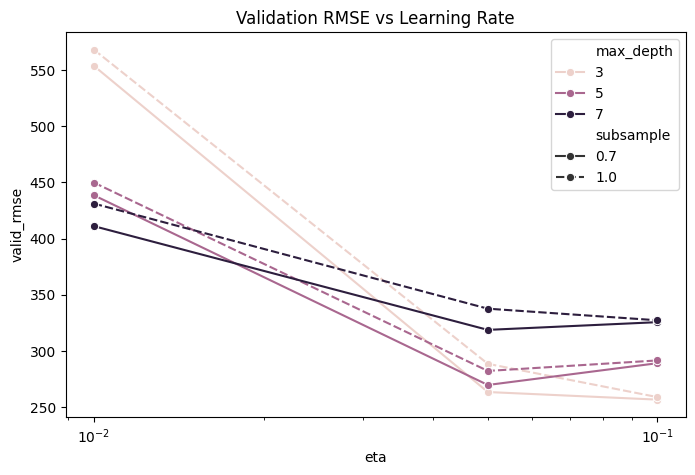

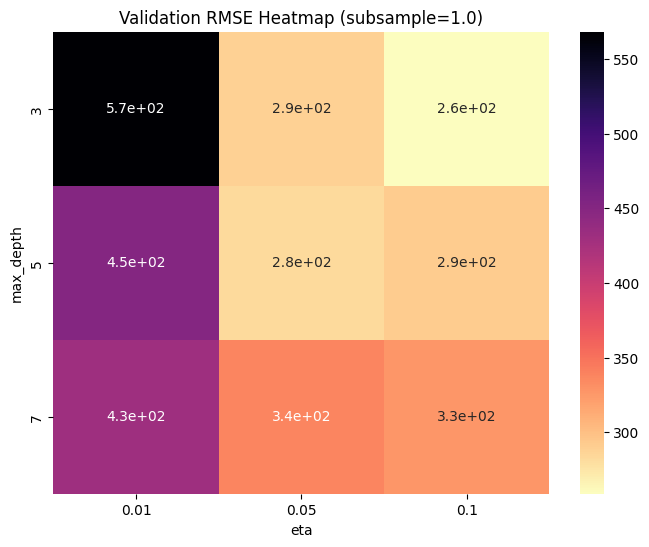

In [8]:
#  10. VISUALIZATION

!pip install seaborn

import seaborn as sns

plt.figure(figsize=(8, 5))
sns.lineplot(data=search_df, x="eta", y="valid_rmse", hue="max_depth", style="subsample", marker="o")
plt.xscale("log")
plt.title("Validation RMSE vs Learning Rate")
plt.show()

# Heatmap for subsample = 1.0
subsample_to_plot = 1.0
plot_df = search_df[search_df["subsample"] == subsample_to_plot]
pivot = plot_df.pivot(index="max_depth", columns="eta", values="valid_rmse")

plt.figure(figsize=(8, 6))
sns.heatmap(pivot, annot=True, cmap="magma_r")
plt.title(f"Validation RMSE Heatmap (subsample={subsample_to_plot})")
plt.show()

Line Graph: As the learnin  rate gets bigger, the model makes fewer misrakes. 


Heatmap: When the learning rate is higher, there are better results. 

In [9]:
#  11. SELECT BEST HYPERPARAMETERS

best_row = search_df.loc[search_df["valid_rmse"].idxmin()]
best_params = {
    **base_params,
    "max_depth": int(best_row["max_depth"]),
    "eta": float(best_row["eta"]),
    "subsample": float(best_row["subsample"]),
}

print("Best hyperparameters:", best_params)

Best hyperparameters: {'objective': 'reg:squarederror', 'tree_method': 'hist', 'eval_metric': 'rmse', 'max_depth': 3, 'eta': 0.1, 'subsample': 0.7}


In [10]:
#  12. RETRAIN FINAL MODEL ON TRAIN + VALID

trainval_ds = train_ds.union(valid_ds)

final_trainer = XGBoostTrainer(
    label_column=LABEL_COL,
    params=best_params,
    scaling_config=ScalingConfig(num_workers=4, use_gpu=False),
    datasets={"train": trainval_ds},
    num_boost_round=200,
)

final_result = final_trainer.fit()

== Status ==
Current time: 2026-06-01 18:55:36 (running for 00:00:00.11)
Using FIFO scheduling algorithm.
Logical resource usage: 5.0/8 CPUs, 0/0 GPUs
Result logdir: /tmp/ray/ray/session_2026-06-01_18-35-34_696613_75041/artifacts/2026-06-01_18-55-36/XGBoostTrainer_2026-06-01_18-55-36/driver_artifacts
Number of trials: 1/1 (1 PENDING)


== Status ==
Current time: 2026-06-01 18:55:41 (running for 00:00:05.16)
Using FIFO scheduling algorithm.
Logical resource usage: 5.0/8 CPUs, 0/0 GPUs
Result logdir: /tmp/ray/ray/session_2026-06-01_18-35-34_696613_75041/artifacts/2026-06-01_18-55-36/XGBoostTrainer_2026-06-01_18-55-36/driver_artifacts
Number of trials: 1/1 (1 RUNNING)




(XGBoostTrainer pid=108047) Started distributed worker processes: 
(XGBoostTrainer pid=108047) - (node_id=db2ae9eb9829b6459e98a8038c3eae12c70bef9939977b5d014db5bb, ip=198.202.101.239, pid=108146) world_rank=0, local_rank=0, node_rank=0
(XGBoostTrainer pid=108047) - (node_id=db2ae9eb9829b6459e98a8038c3eae12c70bef9939977b5d014db5bb, ip=198.202.101.239, pid=108147) world_rank=1, local_rank=1, node_rank=0
(XGBoostTrainer pid=108047) - (node_id=db2ae9eb9829b6459e98a8038c3eae12c70bef9939977b5d014db5bb, ip=198.202.101.239, pid=108149) world_rank=2, local_rank=2, node_rank=0
(XGBoostTrainer pid=108047) - (node_id=db2ae9eb9829b6459e98a8038c3eae12c70bef9939977b5d014db5bb, ip=198.202.101.239, pid=108148) world_rank=3, local_rank=3, node_rank=0
(RayTrainWorker pid=108149) [18:55:45] Task [xgboost.ray-rank=00000002]:05968a93b3cba6496f56600801000000 got rank 2


== Status ==
Current time: 2026-06-01 18:55:46 (running for 00:00:10.17)
Using FIFO scheduling algorithm.
Logical resource usage: 5.0/8 CPUs, 0/0 GPUs
Result logdir: /tmp/ray/ray/session_2026-06-01_18-35-34_696613_75041/artifacts/2026-06-01_18-55-36/XGBoostTrainer_2026-06-01_18-55-36/driver_artifacts
Number of trials: 1/1 (1 RUNNING)




(SplitCoordinator pid=108516) Starting execution of Dataset. Full logs are in /tmp/ray/ray/session_2026-06-01_18-35-34_696613_75041/logs/ray-data
(SplitCoordinator pid=108516) Execution plan of Dataset: InputDataBuffer[Input], InputDataBuffer[Input] -> UnionOperator[UnionOperator(Input, Input)] -> OutputSplitter[split(4, equal=True)]


(pid=108516) Running 0: 0.00 row [00:00, ? row/s]

(pid=108516) - UnionOperator(Input, Input) 1: 0.00 row [00:00, ? row/s]

(pid=108516) - split(4, equal=True) 2: 0.00 row [00:00, ? row/s]

== Status ==
Current time: 2026-06-01 18:55:51 (running for 00:00:15.19)
Using FIFO scheduling algorithm.
Logical resource usage: 5.0/8 CPUs, 0/0 GPUs
Result logdir: /tmp/ray/ray/session_2026-06-01_18-35-34_696613_75041/artifacts/2026-06-01_18-55-36/XGBoostTrainer_2026-06-01_18-55-36/driver_artifacts
Number of trials: 1/1 (1 RUNNING)




(XGBoostTrainer pid=108047) [18:55:51] [0]	train-rmse:673.96544
(XGBoostTrainer pid=108047) [18:55:51] [1]	train-rmse:649.56634
(XGBoostTrainer pid=108047) [18:55:51] [2]	train-rmse:629.16304
(XGBoostTrainer pid=108047) [18:55:51] [3]	train-rmse:610.39739
(XGBoostTrainer pid=108047) [18:55:51] [4]	train-rmse:594.49551
(XGBoostTrainer pid=108047) [18:55:51] [5]	train-rmse:580.61010
(XGBoostTrainer pid=108047) [18:55:51] [6]	train-rmse:568.25561
(XGBoostTrainer pid=108047) [18:55:51] [7]	train-rmse:558.35730
(XGBoostTrainer pid=108047) [18:55:51] [8]	train-rmse:548.51885
(XGBoostTrainer pid=108047) [18:55:51] [9]	train-rmse:539.76741
(XGBoostTrainer pid=108047) [18:55:51] [10]	train-rmse:532.17273
(XGBoostTrainer pid=108047) [18:55:51] [11]	train-rmse:524.73164
(XGBoostTrainer pid=108047) [18:55:51] [12]	train-rmse:518.36978
(XGBoostTrainer pid=108047) [18:55:51] [13]	train-rmse:512.61375
(XGBoostTrainer pid=108047) [18:55:51] [14]	train-rmse:506.32760
(RayTrainWorker pid=108148) [18:55:

== Status ==
Current time: 2026-06-01 18:55:54 (running for 00:00:17.87)
Using FIFO scheduling algorithm.
Logical resource usage: 5.0/8 CPUs, 0/0 GPUs
Result logdir: /tmp/ray/ray/session_2026-06-01_18-35-34_696613_75041/artifacts/2026-06-01_18-55-36/XGBoostTrainer_2026-06-01_18-55-36/driver_artifacts
Number of trials: 1/1 (1 TERMINATED)




In [11]:

# 13. EVALUATE ON TEST SET
booster = xgb.Booster()
booster.load_model(final_result.checkpoint.path + "/model.ubj")

batch_iter = test_ds.iter_batches(batch_size=10_000, batch_format="pandas")

all_true = []
all_pred = []

for batch in batch_iter:
    X = batch[[f"pca_{i}" for i in range(N_COMPONENTS)]]
    y_true = batch[LABEL_COL].to_numpy()

    dmat = xgb.DMatrix(X)
    y_pred = booster.predict(dmat)

    all_true.append(y_true)
    all_pred.append(y_pred)

y_true = np.concatenate(all_true)
y_pred = np.concatenate(all_pred)

print("FINAL TEST METRICS (best hyperparameters)")
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("R²:", r2_score(y_true, y_pred))


FINAL TEST METRICS (best hyperparameters)
RMSE: 198.9542943113376
MAE: 147.85508741590712
R²: -0.2759746692203051
